# Notebook 13: Investment Education Agent (Multi-Turn Chat)

## Learning Objectives
- Build a **linear LangGraph pipeline** with just 2 nodes
- Use **context enrichment** to inject portfolio data into the system prompt
- Support **multi-turn conversation** — ask follow-up questions
- Understand how agents can **share state** via JSON files

## Architecture
```
enrich_context -> call_model -> END
```

## How It Works
1. **enrich_context**: Loads the portfolio (if one exists from Notebook 11) and
   builds an enriched system prompt with holdings, allocations, and sector analysis
2. **call_model**: Sends the system prompt + conversation history to the LLM

The graph is invoked **once per user message** in a chat loop, so the LLM
can give personalised investment education based on your actual portfolio.

## Three-Agent System
| Notebook | Role | Input | Output |
|----------|------|-------|--------|
| **11** (Builder) | Define portfolio | User edits dict | `portfolio.json` |
| **12** (Analytics) | Full scoring & risk | `portfolio.json` | Analysis report |
| **13** (Education) | Interactive chat | `portfolio.json` | Conversational advice |

## How to Use This Notebook

### Prerequisites
1. **Notebook 11 is optional**: If you have run Notebook 11 and exported a portfolio (`../data/outputs/portfolio.json`), this notebook will use it. Otherwise, a **sample portfolio** (VTI, QQQ, XLV, AAPL, JNJ, BND, etc.) is loaded automatically so the notebook works standalone with personalised responses.
2. **Environment file**: Create a `.env` file in the project root (`../.env`) with your API keys:
   ```
   LLM_PROVIDER=openai
   LLM_MODEL=gpt-4.1-mini
   OPENAI_API_KEY=your-openai-key
   ```
3. **Install packages**: The first code cell installs all required packages automatically.

### Running the Notebook
1. **Run All Cells** (recommended): Use `Kernel > Restart & Run All` or click **Run All** to execute every cell top to bottom. The notebook will:
   - Install dependencies and load the portfolio (or use the sample)
   - Build the 2-node education agent graph
   - Run a multi-turn demo conversation
   - Run 7 standalone education demo queries
2. **Run Cell by Cell**: Execute cells one at a time with `Shift + Enter` to step through the logic and observe each output.

### Demo Queries (Cells below)
The notebook includes 7 pre-built education queries covering key investment concepts:

| Demo | Query | What It Teaches |
|------|-------|-----------------|
| 1 | "What is a Sharpe ratio?" | Risk-adjusted return measurement |
| 2 | "Explain diversification." | Portfolio risk reduction strategy |
| 3 | "What is beta?" | Market sensitivity and volatility |
| 4 | "What is dollar-cost averaging?" | Systematic investment strategy |
| 5 | "Should I invest in growth or value stocks?" | Investment style comparison |
| 6 | "How does inflation impact my portfolio?" | Macroeconomic portfolio effects |
| 7 | "What is sector concentration risk?" | Sector allocation risk management |

### Interactive Mode
After the demos, there is an **Interactive Chat** cell where you can have a free-form conversation. The agent remembers previous messages in the same session, so you can ask follow-up questions.

### Portfolio Context
- **With portfolio file**: Responses reference your specific holdings from Notebook 11
- **With sample portfolio**: Responses reference the sample holdings (VTI, QQQ, AAPL, etc.) for concrete examples

## Installation

In [1]:
%pip install langchain langchain-openai langgraph python-dotenv pandas pydantic yfinance --quiet

print("Packages installed")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Packages installed


## Imports

In [2]:
import json
import os
from typing import Annotated, Sequence

import yfinance as yf
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel
from IPython.display import Image, display, Markdown

from ai_course_utils import load_llm_from_env, display_config

# Load environment
load_dotenv()
load_dotenv('../.env')

print("Imports successful")

Imports successful


## Configuration

In [3]:
display_config()

API CONFIGURATION (.env file)
LLM Provider:    openai
LLM Model:       gpt-4.1-mini
Temperature:     0.0

API Keys Status:
  OpenAI               Set
  Google               Not set
  Mistral              Not set
  Anthropic            Not set
  Serper (Web Search)  Set

Data Files:
  Provide file paths as function parameters
  Example: load_use_case_config('your_file.xlsx')


## Load Portfolio

If a portfolio JSON exists from Notebook 11, the Education Agent will
use it to personalise responses. If no portfolio is found, a **sample
portfolio** is used so the agent can still give portfolio-specific
education with concrete examples.

In [4]:
# ============================================================================
# USER INPUT: Path to portfolio JSON from Notebook 11
# ============================================================================
portfolio_file = "../data/outputs/portfolio.json"

# Sample portfolio used when Notebook 11 has not been run yet
SAMPLE_PORTFOLIO = {
    "name": "Sample Balanced Growth Portfolio",
    "description": "A diversified portfolio for demonstration purposes, "
                   "blending broad market ETFs with sector exposure and bonds.",
    "holdings": [
        {"ticker": "VTI",  "company_name": "Vanguard Total Stock Market ETF",
         "allocation_pct": 25.0, "investment_type": "ETF",
         "rationale": "Broad US equity exposure"},
        {"ticker": "QQQ",  "company_name": "Invesco QQQ Trust",
         "allocation_pct": 15.0, "investment_type": "ETF",
         "rationale": "Growth-oriented tech exposure"},
        {"ticker": "XLV",  "company_name": "Health Care Select Sector SPDR Fund",
         "allocation_pct": 10.0, "investment_type": "ETF",
         "rationale": "Healthcare sector tilt"},
        {"ticker": "VWO",  "company_name": "Vanguard FTSE Emerging Markets ETF",
         "allocation_pct": 10.0, "investment_type": "ETF",
         "rationale": "Emerging market diversification"},
        {"ticker": "XLE",  "company_name": "Energy Select Sector SPDR Fund",
         "allocation_pct": 5.0,  "investment_type": "ETF",
         "rationale": "Energy sector and inflation hedge"},
        {"ticker": "AAPL", "company_name": "Apple Inc.",
         "allocation_pct": 10.0, "investment_type": "Stock",
         "rationale": "Large-cap growth with strong cash flow"},
        {"ticker": "JNJ",  "company_name": "Johnson & Johnson",
         "allocation_pct": 5.0,  "investment_type": "Stock",
         "rationale": "Defensive healthcare with dividend income"},
        {"ticker": "BND",  "company_name": "Vanguard Total Bond Market ETF",
         "allocation_pct": 15.0, "investment_type": "Bond ETF",
         "rationale": "Fixed income for stability and income"},
        {"ticker": "GLD",  "company_name": "SPDR Gold Shares",
         "allocation_pct": 5.0,  "investment_type": "Commodity ETF",
         "rationale": "Inflation hedge and portfolio diversifier"},
    ],
}

if os.path.exists(portfolio_file):
    with open(portfolio_file) as f:
        PORTFOLIO = json.load(f)
    print(f"Portfolio loaded from {portfolio_file}")
else:
    PORTFOLIO = SAMPLE_PORTFOLIO
    print(f"No portfolio file found at {portfolio_file}")
    print("Using SAMPLE portfolio for demonstration\n")

print(f"  Name: {PORTFOLIO['name']}")
print(f"  Holdings: {len(PORTFOLIO['holdings'])}")
print()
for h in PORTFOLIO['holdings']:
    print(f"  {h['ticker']:<6} {h['allocation_pct']:>5.1f}%  {h['company_name']}")

No portfolio file found at ../data/outputs/portfolio.json
Using SAMPLE portfolio for demonstration

  Name: Sample Balanced Growth Portfolio
  Holdings: 9

  VTI     25.0%  Vanguard Total Stock Market ETF
  QQQ     15.0%  Invesco QQQ Trust
  XLV     10.0%  Health Care Select Sector SPDR Fund
  VWO     10.0%  Vanguard FTSE Emerging Markets ETF
  XLE      5.0%  Energy Select Sector SPDR Fund
  AAPL    10.0%  Apple Inc.
  JNJ      5.0%  Johnson & Johnson
  BND     15.0%  Vanguard Total Bond Market ETF
  GLD      5.0%  SPDR Gold Shares


## S&P 500 Sector Benchmark

Used by the context enrichment node to compare your portfolio sectors
against the market benchmark.

In [5]:
SP500_SECTOR_WEIGHTS = {
    "Technology": 31.0,
    "Healthcare": 12.0,
    "Financial Services": 13.0,
    "Consumer Cyclical": 10.0,
    "Communication Services": 9.0,
    "Industrials": 8.0,
    "Consumer Defensive": 6.0,
    "Energy": 4.0,
    "Utilities": 3.0,
    "Real Estate": 2.0,
    "Basic Materials": 2.0,
}

print("S&P 500 sector benchmark loaded")

S&P 500 sector benchmark loaded


## Define Education State

The state has:
- `messages`: Conversation history (Human and AI messages). Uses the
  `add_messages` reducer to append rather than replace.
- `system_prompt`: The full system prompt, rebuilt each turn with
  current portfolio context. Stored separately from `messages` to
  avoid reducer ordering issues.
- `portfolio_context`: Populated with portfolio data if one exists.

In [6]:
class EducationState(BaseModel):
    """State that flows through the education agent graph.

    The system prompt is stored separately from messages to avoid
    reducer ordering issues — it gets prepended at LLM call time.
    """

    model_config = {"arbitrary_types_allowed": True}

    messages: Annotated[Sequence[BaseMessage], add_messages] = []
    system_prompt: str = ""
    portfolio_context: str = ""


print("EducationState defined")
print("  Fields: messages, system_prompt, portfolio_context")

EducationState defined
  Fields: messages, system_prompt, portfolio_context


## Education System Prompt

This is the base system prompt for the education agent. Portfolio context
will be appended to it if a portfolio exists.

In [7]:
EDUCATION_PROMPT = """You are an expert investment education assistant. \
Your role is to help users understand investment concepts, portfolio \
management, and financial markets.

Guidelines:
- Explain concepts clearly using plain language
- Use real-world examples when possible
- If the user has a portfolio, reference their specific holdings to \
make explanations more relevant and personalised
- Cover topics like: asset allocation, diversification, risk management, \
technical analysis (RSI, MACD, SMA), fundamental analysis (P/E, P/B, ROE), \
sector rotation, rebalancing, dividend investing, growth vs value
- Always remind users that this is for educational purposes only and \
not financial advice
- When discussing the user's portfolio, explain the "why" behind \
observations (e.g. why being overweight in tech increases volatility)
- Be conversational and encourage follow-up questions"""

print("Education prompt defined")

Education prompt defined


## Sector Comparison Helper

Compares the portfolio's sector weights against S&P 500 benchmarks.
This context is injected into the system prompt so the LLM can give
personalised advice about sector exposure.

In [8]:
def compute_sector_comparison(holdings: list[dict]) -> str:
    """Compare portfolio sector weights against S&P 500.

    Args:
        holdings: List of dicts with 'ticker' and 'allocation_pct' keys.

    Returns:
        Text summary of sector weight comparison.
    """
    if not holdings:
        return ""

    # Fetch sector for each ticker
    sector_weights = {}
    for h in holdings:
        try:
            info = yf.Ticker(h["ticker"]).info
            sector = info.get("sector", "Unknown")
        except Exception:
            sector = "Unknown"
        sector_weights[sector] = sector_weights.get(sector, 0) + h.get("allocation_pct", 0)

    # Build comparison
    lines = ["Sector Allocation Comparison (Portfolio vs S&P 500):"]
    all_sectors = sorted(set(list(SP500_SECTOR_WEIGHTS.keys()) + list(sector_weights.keys())))

    for sector in all_sectors:
        port_w = sector_weights.get(sector, 0)
        sp_w = SP500_SECTOR_WEIGHTS.get(sector, 0)
        diff = port_w - sp_w
        if port_w > 0 or abs(diff) > 3:
            status = "OVERWEIGHT" if diff > 5 else "UNDERWEIGHT" if diff < -5 else "NEUTRAL"
            lines.append(
                f"  {sector}: Portfolio {port_w:.1f}% vs S&P 500 {sp_w:.1f}% "
                f"({diff:+.1f}%) [{status}]"
            )

    lines.append("\nOverweight = more than S&P 500 benchmark; underweight = less.")

    return "\n".join(lines)


print("compute_sector_comparison defined")

compute_sector_comparison defined


## Define Pipeline Nodes

Two nodes in a straight line:

```
enrich_context -> call_model -> END
```

- **enrich_context**: Builds the system prompt with portfolio context
- **call_model**: Sends system prompt + messages to the LLM

In [9]:
def enrich_context(state: EducationState) -> dict:
    """Node 1: Build an enriched system prompt with portfolio context.

    If a portfolio exists (from Notebook 11), injects holdings,
    allocations, and sector comparison into the system prompt.
    Otherwise, uses the base education prompt as-is.
    """
    base_prompt = EDUCATION_PROMPT
    portfolio_context = ""

    if PORTFOLIO and PORTFOLIO.get("holdings"):
        holdings = PORTFOLIO["holdings"]
        tickers = [h["ticker"] for h in holdings]

        portfolio_context = (
            f"USER'S CURRENT PORTFOLIO:\n"
            f"Securities: {', '.join(tickers)}.\n"
        )

        # Add allocations
        allocations = [
            f"{h['ticker']} ({h.get('allocation_pct', 0)}%)"
            for h in holdings if h.get("allocation_pct")
        ]
        if allocations:
            portfolio_context += f"Allocations: {', '.join(allocations)}.\n"

        # Add sector comparison
        holdings_for_comparison = [
            {"ticker": h["ticker"], "allocation_pct": h.get("allocation_pct", 0)}
            for h in holdings
        ]
        sector_text = compute_sector_comparison(holdings_for_comparison)
        if sector_text:
            portfolio_context += f"\n{sector_text}\n"

    full_prompt = base_prompt + (f"\n\n{portfolio_context}" if portfolio_context else "")

    return {"system_prompt": full_prompt, "portfolio_context": portfolio_context}


print("Node 1: enrich_context")

Node 1: enrich_context


In [10]:
def call_model(state: EducationState) -> dict:
    """Node 2: Call the LLM with the system prompt + conversation history.

    Prepends the system prompt to the conversation history before
    invoking the model. The system prompt is NOT stored in messages
    to avoid reducer duplication.
    """
    llm = load_llm_from_env()
    messages_for_llm = [SystemMessage(content=state.system_prompt)] + list(state.messages)
    response = llm.invoke(messages_for_llm)
    return {"messages": [response]}


print("Node 2: call_model")

Node 2: call_model


## Build the Linear Graph

Two nodes, one edge:

```
enrich_context -> call_model -> END
```

In [11]:
graph_builder = StateGraph(EducationState)

graph_builder.add_node("enrich_context", enrich_context)
graph_builder.add_node("call_model", call_model)

graph_builder.set_entry_point("enrich_context")
graph_builder.add_edge("enrich_context", "call_model")
graph_builder.add_edge("call_model", END)

graph = graph_builder.compile()

print("Education agent compiled")
print("  enrich_context -> call_model -> END")

Education agent compiled
  enrich_context -> call_model -> END


## Visualise the Graph

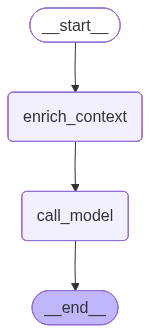

In [12]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("(Graph visualisation requires extra dependencies — skipping)")

## Demo: Single Question

Try a single question first to see how the agent responds.
If a portfolio exists, the answer will reference your holdings.

In [13]:
# Single question demo
result = graph.invoke(
    EducationState(
        messages=[HumanMessage(content="What is diversification and why does it matter?")]
    )
)

display(Markdown(result["messages"][-1].content))

Loading LLM: openai / gpt-4.1-mini


Great question! Diversification is an investment strategy that involves spreading your money across different assets, sectors, or geographic regions to reduce risk. The idea is that by not putting all your eggs in one basket, you can protect your portfolio from big losses if one investment or sector performs poorly.

Why does diversification matter? Because different assets often react differently to the same economic events. For example, when the stock market drops, bonds or gold might hold their value or even go up, helping to cushion your overall portfolio losses.

Looking at your portfolio, you already have a good level of diversification:

- You hold broad U.S. stock market exposure through VTI (25%) and QQQ (15%), which cover many companies and sectors.
- You have international exposure with VWO (10%), which invests in emerging markets.
- You own sector-specific ETFs like XLV (healthcare, 10%) and XLE (energy, 5%).
- You also hold individual stocks like AAPL (technology, 10%) and JNJ (healthcare, 5%).
- Plus, you have bonds (BND, 15%) and gold (GLD, 5%) which add fixed income and alternative asset diversification.

One thing to note is your sector allocation shows you are underweight in many sectors compared to the S&P 500, especially in financials, consumer cyclical, and communication services. This means your portfolio is more concentrated in certain areas, which can increase risk if those sectors underperform.

In summary, diversification helps smooth out returns and reduce volatility. Your portfolio is diversified across asset classes and regions, but you might want to consider if you want more balanced sector exposure depending on your risk tolerance and investment goals.

Feel free to ask if you want me to explain how to diversify further or how to rebalance your portfolio! Just a reminder, this is educational and not financial advice.

## Inspect: Enriched System Prompt

See the full system prompt that was sent to the LLM, including
portfolio context and sector comparison.

In [14]:
print("=" * 70)
print("ENRICHED SYSTEM PROMPT")
print("=" * 70)
print(result["system_prompt"])
print("=" * 70)

if result["portfolio_context"]:
    print("\nPortfolio context was injected")
else:
    print("\nNo portfolio context (general education mode)")

ENRICHED SYSTEM PROMPT
You are an expert investment education assistant. Your role is to help users understand investment concepts, portfolio management, and financial markets.

Guidelines:
- Explain concepts clearly using plain language
- Use real-world examples when possible
- If the user has a portfolio, reference their specific holdings to make explanations more relevant and personalised
- Cover topics like: asset allocation, diversification, risk management, technical analysis (RSI, MACD, SMA), fundamental analysis (P/E, P/B, ROE), sector rotation, rebalancing, dividend investing, growth vs value
- Always remind users that this is for educational purposes only and not financial advice
- When discussing the user's portfolio, explain the "why" behind observations (e.g. why being overweight in tech increases volatility)
- Be conversational and encourage follow-up questions

USER'S CURRENT PORTFOLIO:
Securities: VTI, QQQ, XLV, VWO, XLE, AAPL, JNJ, BND, GLD.
Allocations: VTI (25.0%), Q

## Multi-Turn Conversation

The education agent supports multi-turn chat. Each invocation:
1. Re-enriches the system prompt (in case portfolio changed)
2. Sends the full conversation history to the LLM
3. Appends the response via the `add_messages` reducer

The `chat()` helper below manages the conversation state across turns.

In [15]:
class EducationChat:
    """Multi-turn chat wrapper around the education agent graph.

    Maintains conversation history across invocations so the LLM
    can reference earlier questions and answers.
    """

    def __init__(self, graph):
        self.graph = graph
        self.conversation_history: list[BaseMessage] = []

    def ask(self, question: str) -> str:
        """Send a question and get a response.

        The full conversation history is passed to the graph each time,
        enabling multi-turn context.
        """
        # Add the new question to history
        self.conversation_history.append(HumanMessage(content=question))

        # Invoke the graph with full history
        result = self.graph.invoke(
            EducationState(messages=self.conversation_history)
        )

        # Extract the AI response (last message)
        ai_message = result["messages"][-1]
        self.conversation_history.append(ai_message)

        return ai_message.content

    def reset(self):
        """Clear conversation history to start fresh."""
        self.conversation_history = []
        print("Conversation history cleared")

    def show_history(self):
        """Display the full conversation history."""
        print("=" * 70)
        print("CONVERSATION HISTORY")
        print("=" * 70)
        for i, msg in enumerate(self.conversation_history):
            role = "USER" if isinstance(msg, HumanMessage) else "AI"
            print(f"\n[{i+1}] {role}:")
            print(msg.content[:200] + ("..." if len(msg.content) > 200 else ""))
        print("=" * 70)


# Create the chat instance
chat = EducationChat(graph)

print("EducationChat ready")
print("  Usage: response = chat.ask('your question here')")
print("  Reset: chat.reset()")
print("  History: chat.show_history()")

EducationChat ready
  Usage: response = chat.ask('your question here')
  Reset: chat.reset()
  History: chat.show_history()


## Try a Multi-Turn Conversation

Ask a series of questions. The agent remembers earlier exchanges
and can reference your portfolio holdings.

In [16]:
response = chat.ask("What is the difference between growth and value investing?")
display(Markdown(response))

Loading LLM: openai / gpt-4.1-mini


Great question! Understanding the difference between growth and value investing is fundamental to building an investment strategy.

**Growth Investing** focuses on companies expected to grow their earnings or revenues faster than the overall market. These companies often reinvest profits to expand, innovate, or capture market share rather than paying high dividends. Growth stocks tend to have higher price-to-earnings (P/E) ratios because investors are willing to pay a premium for future growth potential. Examples include many tech companies or emerging industries.

**Value Investing** looks for companies that appear undervalued compared to their fundamentals, such as earnings, book value, or dividends. Value investors seek stocks trading at a discount, often with lower P/E or price-to-book (P/B) ratios, expecting the market to eventually recognize their true worth. These companies might be more established, with stable cash flows and sometimes higher dividend yields.

**Real-world example:**
- Apple (AAPL) in your portfolio is often considered a growth stock because of its innovation and strong earnings growth.
- Johnson & Johnson (JNJ) is more of a value stock, known for steady dividends and stable earnings in healthcare.

**Why it matters for your portfolio:**
Your portfolio has a mix of both growth (AAPL, QQQ which is tech-heavy) and value (JNJ, BND bond fund) elements. This blend can help balance potential high returns from growth stocks with the stability and income from value stocks and bonds.

Would you like me to explain how this mix affects your portfolio’s risk and return, or how you might adjust allocations based on your goals? Remember, this is educational and not financial advice!

In [17]:
response = chat.ask("Based on my portfolio, would you say I lean more towards growth or value?")
display(Markdown(response))

Loading LLM: openai / gpt-4.1-mini


Looking at your portfolio, you lean more toward **growth investing**, but with a meaningful dose of stability and diversification.

Here’s why:

- **Growth elements:**  
  - **QQQ (15%)** is heavily weighted toward technology and growth-oriented companies.  
  - **AAPL (10%)** is a classic growth stock with strong innovation and earnings growth.  
  - **VTI (25%)** is a total U.S. stock market ETF, which includes both growth and value stocks but tends to have a significant growth component given the market’s tech weight.  
  - **VWO (10%)** is an emerging markets ETF, which often includes growth companies in developing economies.

- **Value and stability elements:**  
  - **JNJ (5%)** is a healthcare stock with value characteristics—stable earnings, dividends, and less volatility.  
  - **BND (15%)** is a bond fund, providing income and lower risk, which balances the growth tilt.  
  - **GLD (5%)** gold adds a defensive, non-correlated asset.  
  - **XLV (10%)** healthcare sector ETF, which tends to be more value-oriented and defensive compared to tech.

Your portfolio’s tech exposure (QQQ + AAPL) and emerging markets tilt push it toward growth, while your bond allocation and healthcare holdings add value and defensive qualities.

**Why this matters:**  
Growth stocks can offer higher returns but come with more volatility. Your bond and healthcare allocations help reduce overall risk and provide income, which is a smart way to balance growth ambitions with risk management.

If you want, I can help you analyze how this growth-value mix might perform in different market environments or suggest ways to adjust it based on your risk tolerance or investment goals. Just let me know!

(Reminder: This is for educational purposes only, not financial advice.)

In [18]:
response = chat.ask("What is RSI and how would I use it to evaluate my holdings?")
display(Markdown(response))

Loading LLM: openai / gpt-4.1-mini


Great question! RSI, or **Relative Strength Index**, is a popular technical analysis tool that helps investors gauge whether a stock or other asset might be overbought or oversold.

### What is RSI?

- RSI is a momentum oscillator that measures the speed and change of price movements.
- It ranges from 0 to 100.
- Traditionally, an RSI above 70 suggests the asset might be **overbought** (potentially overvalued and due for a pullback).
- An RSI below 30 suggests the asset might be **oversold** (potentially undervalued and due for a bounce).

### How is RSI calculated?

Without going too deep into math, RSI compares the magnitude of recent gains to recent losses over a set period (usually 14 days) to determine momentum.

### How to use RSI to evaluate your holdings?

Let’s say you want to check the RSI of **AAPL** or **QQQ**:

- If AAPL’s RSI is above 70, it might indicate the stock has risen quickly and could be due for a short-term pullback. You might consider this when deciding whether to buy more, hold, or take some profits.
- If JNJ’s RSI is below 30, it might suggest the stock is oversold and could be a buying opportunity if you believe in its fundamentals.

### Important notes:

- RSI is best used in combination with other indicators or fundamental analysis. For example, a high RSI in a strong uptrend might not mean “sell” immediately.
- It works better in markets that are trading sideways rather than strong trends.
- Since your portfolio includes ETFs like VTI and QQQ, you can check their RSI to get a sense of overall market momentum in those segments.

### Example:

If QQQ’s RSI is 75, it might be signaling that tech stocks are overbought right now, so you might be cautious about adding more tech exposure immediately.

Would you like me to show you how to find RSI values for your holdings or explain other technical indicators like MACD or SMA? Just ask!

(Reminder: This is educational and not financial advice.)

In [19]:
response = chat.ask(
    "You mentioned growth vs value earlier. "
    "How does sector concentration relate to that? "
    "Am I too concentrated in any one sector?"
)
display(Markdown(response))

Loading LLM: openai / gpt-4.1-mini


Excellent follow-up! Sector concentration and the growth vs. value style are closely linked because certain sectors tend to lean more toward growth or value characteristics.

### How sector concentration relates to growth vs. value:

- **Technology sector** is often associated with **growth** stocks. These companies typically reinvest earnings to fuel rapid expansion and innovation. Your portfolio’s tech exposure (AAPL + QQQ) is a big part of your growth tilt.
- **Healthcare** can be a mix but often leans toward **value** because many companies have stable earnings and dividends (like JNJ and XLV in your portfolio).
- **Financials, Energy, Industrials, Consumer Defensive** sectors often have more **value** stocks, with established companies paying dividends and trading at lower valuations.
- **Consumer Cyclical** can be growth or value depending on the company, but often includes growth-oriented retailers or automakers.

### Your portfolio’s sector concentration:

- You have **no direct exposure** to Communication Services, Consumer Cyclical, Financial Services, Industrials, or Consumer Defensive sectors, which means you’re **underweight** compared to the S&P 500 in those areas.
- Your portfolio is **overweight in “Unknown” (85%)**, which likely reflects your holdings in broad ETFs like VTI, QQQ, VWO, and individual stocks that don’t map neatly to one sector in this analysis.
- You have a **moderate allocation to Healthcare (15% combined JNJ + XLV)** and **Energy (5% XLE)**.
- Your **Technology exposure (AAPL + QQQ)** is about 25%, which is **underweight compared to the S&P 500’s 31% tech weight**, but still a significant chunk.

### Are you too concentrated?

- You’re somewhat concentrated in **tech and growth-oriented assets** (QQQ + AAPL), which can increase portfolio volatility because tech stocks tend to be more sensitive to market swings.
- The lack of exposure to sectors like Financials or Consumer Defensive means you might miss out on diversification benefits and the defensive qualities those sectors can provide.
- Your bond allocation (BND 15%) and gold (GLD 5%) help reduce overall risk and add diversification outside equities.

### Why diversification matters:

- Different sectors perform better in different economic environments. For example, Financials often do well when interest rates rise, while Consumer Defensive stocks can hold up better during downturns.
- Having a mix of sectors can smooth out returns and reduce risk.

### Summary:

Your portfolio leans growth with a tech tilt but is missing some sector diversification that could add stability and value exposure. Depending on your risk tolerance and goals, you might consider adding some exposure to underrepresented sectors for better balance.

Would you like help exploring how to diversify sector exposure or how sector rotation strategies work? Just let me know!

(Reminder: This is educational, not financial advice.)

## View Conversation History

In [20]:
chat.show_history()

CONVERSATION HISTORY

[1] USER:
What is the difference between growth and value investing?

[2] AI:
Great question! Understanding the difference between growth and value investing is fundamental to building an investment strategy.

**Growth Investing** focuses on companies expected to grow their ear...

[3] USER:
Based on my portfolio, would you say I lean more towards growth or value?

[4] AI:
Looking at your portfolio, you lean more toward **growth investing**, but with a meaningful dose of stability and diversification.

Here’s why:

- **Growth elements:**  
  - **QQQ (15%)** is heavily w...

[5] USER:
What is RSI and how would I use it to evaluate my holdings?

[6] AI:
Great question! RSI, or **Relative Strength Index**, is a popular technical analysis tool that helps investors gauge whether a stock or other asset might be overbought or oversold.

### What is RSI?

...

[7] USER:
You mentioned growth vs value earlier. How does sector concentration relate to that? Am I too concentra

## Demo: Investment Education Queries

Each demo sends a standalone investment education question to the agent.
The chat is reset first so each question gets an independent answer.
If a portfolio is loaded, responses will reference your specific holdings.

In [21]:
# Reset for standalone demos
chat.reset()

# Demo 1: Sharpe ratio
print("=" * 70)
print("Demo 1: Sharpe Ratio")
print("=" * 70)

print("\nUser: What is a Sharpe ratio?")
response = chat.ask("What is a Sharpe ratio?")
print(f"\nBot: {response}")

Conversation history cleared
Demo 1: Sharpe Ratio

User: What is a Sharpe ratio?
Loading LLM: openai / gpt-4.1-mini

Bot: Great question! The Sharpe ratio is a popular measure used to understand the risk-adjusted return of an investment or a portfolio.

**In simple terms:**
- It tells you how much excess return (above a "risk-free" rate like U.S. Treasury bills) you are getting for each unit of risk you take.
- The higher the Sharpe ratio, the better the return you’re getting relative to the risk.

**How it’s calculated:**
Sharpe Ratio = (Portfolio Return – Risk-Free Rate) / Portfolio Standard Deviation (Risk)

- **Portfolio Return:** The average return of your investment or portfolio.
- **Risk-Free Rate:** The return of a "safe" investment, often U.S. Treasury bills.
- **Standard Deviation:** A measure of how much the returns fluctuate (volatility or risk).

**Why it matters:**
- If two portfolios have the same return, the one with less risk (lower volatility) will have a higher Sharp

In [22]:
# Demo 2: Diversification
chat.reset()

print("=" * 70)
print("Demo 2: Diversification")
print("=" * 70)

print("\nUser: Explain diversification.")
response = chat.ask("Explain diversification.")
print(f"\nBot: {response}")

Conversation history cleared
Demo 2: Diversification

User: Explain diversification.
Loading LLM: openai / gpt-4.1-mini

Bot: Great question! Diversification is a fundamental investment concept that means spreading your investments across different assets, sectors, or geographic regions to reduce risk.

Think of it like not putting all your eggs in one basket. If one investment performs poorly, others may perform better, helping to balance out your overall portfolio performance.

For example, in your portfolio, you hold a mix of:

- U.S. total stock market (VTI)
- Nasdaq tech-heavy index (QQQ)
- Healthcare sector (XLV, JNJ)
- Emerging markets (VWO)
- Energy sector (XLE)
- Individual stocks (AAPL, JNJ)
- Bonds (BND)
- Gold (GLD)

This mix provides diversification across asset classes (stocks, bonds, gold), sectors (technology, healthcare, energy), and regions (U.S. and emerging markets).

Why is this helpful? Because different assets often react differently to economic events. For insta

In [23]:
# Demo 3: Beta
chat.reset()

print("=" * 70)
print("Demo 3: Beta")
print("=" * 70)

print("\nUser: What is beta?")
response = chat.ask("What is beta?")
print(f"\nBot: {response}")

Conversation history cleared
Demo 3: Beta

User: What is beta?
Loading LLM: openai / gpt-4.1-mini

Bot: Great question! Beta is a measure used in investing to understand how much a particular stock or portfolio tends to move compared to the overall market. 

Here’s a simple way to think about it:

- The market (often represented by an index like the S&P 500) has a beta of 1.
- If a stock or portfolio has a beta greater than 1, it means it tends to be more volatile than the market. For example, a beta of 1.5 suggests the stock might move 1.5 times as much as the market does. So if the market goes up 10%, the stock might go up 15%, but if the market drops 10%, the stock might drop 15%.
- If a beta is less than 1, the stock is less volatile than the market. For example, a beta of 0.5 means it moves about half as much as the market.
- A beta of 0 means the stock’s price doesn’t move with the market at all (like some bonds or cash equivalents).

Why does beta matter? It helps investors unde

In [24]:
# Demo 4: Dollar-cost averaging
chat.reset()

print("=" * 70)
print("Demo 4: Dollar-Cost Averaging")
print("=" * 70)

print("\nUser: What is dollar-cost averaging?")
response = chat.ask("What is dollar-cost averaging?")
print(f"\nBot: {response}")

Conversation history cleared
Demo 4: Dollar-Cost Averaging

User: What is dollar-cost averaging?
Loading LLM: openai / gpt-4.1-mini

Bot: Great question! Dollar-cost averaging (DCA) is an investment strategy where you invest a fixed amount of money at regular intervals, regardless of the asset’s price. Instead of trying to time the market by buying all at once, you spread out your purchases over time.

Here’s how it works in simple terms:

- Suppose you decide to invest $500 every month into a particular stock or fund.
- When prices are high, your $500 buys fewer shares.
- When prices are low, your $500 buys more shares.
- Over time, this can lower your average cost per share compared to investing a lump sum at once.

For example, if you invested $500 monthly into your VTI holding, you’d buy more shares when the market dips and fewer when it rises, potentially smoothing out the impact of volatility.

Why use dollar-cost averaging?

- It reduces the risk of investing a large amount righ

In [25]:
# Demo 5: Growth vs value
chat.reset()

print("=" * 70)
print("Demo 5: Growth vs Value Stocks")
print("=" * 70)

print("\nUser: Should I invest in growth or value stocks?")
response = chat.ask("Should I invest in growth or value stocks?")
print(f"\nBot: {response}")

Conversation history cleared
Demo 5: Growth vs Value Stocks

User: Should I invest in growth or value stocks?
Loading LLM: openai / gpt-4.1-mini

Bot: Great question! The choice between growth and value stocks depends on your investment goals, risk tolerance, and time horizon. Let me break down the basics for you:

**Growth Stocks:**
- These are companies expected to grow earnings faster than the overall market.
- They often reinvest profits to expand rather than pay dividends.
- Examples: Technology companies like Apple (AAPL) in your portfolio.
- Tend to be more volatile but offer higher potential returns over the long term.
- Investors buy growth stocks to capitalize on future earnings growth.

**Value Stocks:**
- These are companies that appear undervalued based on metrics like price-to-earnings (P/E) or price-to-book (P/B) ratios.
- Often more established firms with stable earnings and dividends.
- Tend to be less volatile and may provide income through dividends.
- Investors buy 

In [26]:
# Demo 6: Inflation impact
chat.reset()

print("=" * 70)
print("Demo 6: Inflation Impact")
print("=" * 70)

print("\nUser: How does inflation impact my portfolio?")
response = chat.ask("How does inflation impact my portfolio?")
print(f"\nBot: {response}")

Conversation history cleared
Demo 6: Inflation Impact

User: How does inflation impact my portfolio?
Loading LLM: openai / gpt-4.1-mini

Bot: Great question! Inflation is the general rise in prices over time, which means your money buys less than before. It can impact your portfolio in several ways:

1. **Eroding Purchasing Power:** If your investments don’t grow faster than inflation, your real returns (adjusted for inflation) could be negative. For example, if inflation is 4% but your portfolio grows 3%, you’re effectively losing purchasing power.

2. **Impact on Bonds (BND):** Bonds are sensitive to inflation because they pay fixed interest. When inflation rises, bond yields usually go up, causing bond prices to fall. Since you have 15% in BND (a bond ETF), rising inflation could reduce the value of that part of your portfolio.

3. **Stocks (VTI, QQQ, AAPL, JNJ, XLV, VWO, XLE):** Stocks can be a good hedge against inflation over the long term because companies can raise prices to ke

In [27]:
# Demo 7: Sector concentration risk
chat.reset()

print("=" * 70)
print("Demo 7: Sector Concentration Risk")
print("=" * 70)

print("\nUser: What is sector concentration risk?")
response = chat.ask("What is sector concentration risk?")
print(f"\nBot: {response}")

Conversation history cleared
Demo 7: Sector Concentration Risk

User: What is sector concentration risk?
Loading LLM: openai / gpt-4.1-mini

Bot: Great question! Sector concentration risk refers to the potential risk that comes from having a large portion of your investment portfolio concentrated in one or a few specific sectors of the economy. When your portfolio is heavily weighted toward certain sectors, it becomes more vulnerable to negative events or downturns that impact those sectors specifically.

For example, if you had 70% of your portfolio in the technology sector and the tech industry faced a regulatory crackdown or a major innovation slowdown, your portfolio could suffer significant losses because it’s not diversified enough across other sectors that might perform better in that environment.

Looking at your portfolio, you have a mix of broad ETFs like VTI (total U.S. stock market) and QQQ (tech-heavy Nasdaq 100), plus sector-specific ETFs like XLV (healthcare) and XLE (en

## Interactive Chat Loop

Run this cell for a free-form interactive chat session.
Type `quit` or `exit` to stop.

In [28]:
# Reset conversation for a fresh interactive session
chat.reset()

print("=" * 70)
print("INVESTMENT EDUCATION CHAT")
print("=" * 70)
if PORTFOLIO:
    tickers = [h['ticker'] for h in PORTFOLIO['holdings']]
    print(f"Portfolio loaded: {', '.join(tickers)}")
else:
    print("No portfolio loaded (general education mode)")
print("Type 'quit' or 'exit' to stop.")
print("=" * 70)

while True:
    user_input = input("\nYou: ").strip()
    if not user_input:
        continue
    if user_input.lower() in ("quit", "exit", "q"):
        print("\nChat ended. Use chat.show_history() to review.")
        break

    response = chat.ask(user_input)
    print(f"\nAI: {response}")

Conversation history cleared
INVESTMENT EDUCATION CHAT
Portfolio loaded: VTI, QQQ, XLV, VWO, XLE, AAPL, JNJ, BND, GLD
Type 'quit' or 'exit' to stop.

Chat ended. Use chat.show_history() to review.


## Example Questions to Try

Here are some good questions to ask the education agent:

**General concepts:**
- "What is dollar-cost averaging?"
- "Explain the difference between ETFs and mutual funds"
- "What is a golden cross in technical analysis?"

**Portfolio-specific (if portfolio loaded):**
- "Is my portfolio well diversified?"
- "Which of my holdings has the most risk?"
- "Should I add bonds to balance my portfolio?"
- "What would happen to my portfolio in a recession?"

**Follow-up questions:**
- "Can you explain that in simpler terms?"
- "How does that apply to my specific holdings?"
- "What would you recommend I learn next?"

In [29]:
# Try your own question:
# response = chat.ask("Your question here")
# display(Markdown(response))

## Summary

- Investment Education Agent with a 2-node linear LangGraph pipeline
- Context enrichment: injects portfolio holdings and sector analysis into the system prompt
- Multi-turn conversation: maintains chat history across invocations
- Portfolio-aware: personalises responses based on your actual holdings
- Graceful fallback: works as a general education chatbot if no portfolio exists

### Architecture
```
enrich_context -> call_model -> END
```

### Three-Agent System
```
Notebook 11 (Builder)    -> portfolio.json -> Notebook 12 (Analytics)
                         -> portfolio.json -> Notebook 13 (Education)
```

| Feature | Notebook 12 (Analytics) | Notebook 13 (Education) |
|---------|------------------------|-------------------------|
| Graph nodes | 5 (full pipeline) | 2 (enrich + call) |
| LLM calls | 2 (analysis + signals) | 1 per turn |
| Output | One-shot report | Multi-turn conversation |
| Data work | Full scoring, risk | Context enrichment only |
| Use case | Portfolio analysis | Investment education |